In [1]:
import os
import re

import numpy as np
import torch
import pandas as pd
import matplotlib
import seaborn as sns
import pickle
from tqdm.notebook import tqdm
from scipy.interpolate import interp1d
from functionsgpu_old import *
from plotting_betas import *
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from video_saving import *
from plotting_beta import *

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(device)
dtype = torch.float32

def deterministic():
    SEED = 42
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    # Enable deterministic operations (may slow down training slightly)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

deterministic()
tslen = 200

cuda:1


In [2]:
def z_create(X, encode_fn, mu_all_t_tensor):
    z = encode_fn(X)
    std_dev = torch.std(z, dim=0)
    order = torch.argsort(std_dev, descending=True)
    z = z[:, order]
    std_dev = std_dev[order]
    z_mean = encode_fn(mu_all_t_tensor.view(1, -1))
    z_mean = z_mean[:, order]
    return z, z_mean, std_dev


def z_plot(z, z_mean, beta=1e-5):
    zdf_all = pd.DataFrame(z.cpu().detach().numpy(), columns=["z{}".format(i+1) for i in range(z.shape[1])])
    zdf_all.loc[:44, 'cohort'] = 'stroke'
    zdf_all.loc[44:, 'cohort'] = 'control'

    # zdf_subset = zdf_all[['z1', 'z2','z3','cohort']]
    zdf_subset = zdf_all[['z1', 'z2','cohort']]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(zdf_all.select_dtypes(include=['number']).corr(), fmt=".1f", annot=True, ax=ax1)
    sns.scatterplot(data=zdf_subset, x='z1', y='z2', hue='cohort', ax=ax2)
    ax2.plot(z_mean[0, 0].cpu().detach().numpy(), z_mean[0, 1].cpu().detach().numpy(), 'k*', markersize=10, label='mean')
    ax2.legend()
    plt.suptitle(f'beta_kl = {beta}')
    plt.tight_layout()
    plt.show()


def skeleton_mode(tangent_vec_all, mu_all_t_tensor, z_mean, std_dev, R, ae_decode):
    K, M, T = tangent_vec_all.shape[:3]
    scales = [-2, 0, 2]
    betas_hat = []
    z_mode = torch.zeros(1, R, dtype=dtype)

    for r in range(R):
        for s in scales:
            z_mode = z_mean.clone()
            z_mode[:, r] = z_mean[:, r] + s * std_dev[r]
            # z_mode[:, r] = s
            with torch.no_grad():
                v = ae_decode(z_mode)
            v = v.reshape(K, M, T)
            beta_hat = exp_gpu(mu_all_t_tensor, v)
            betas_hat.append(beta_hat.detach().cpu().numpy())

        p_all = plotting_betas_landmark([betas_hat[-3], betas_hat[-2], betas_hat[-1]], 
                                        colors=[(1, 0, 0), (0, 0, 0), (0, 0.5, 1)])
    # video_saving(p_all, 'AE{}'.format(r+1))
    return betas_hat

In [2]:
def loading(filename, tslen):
    with open('{}/betas_aligned{}.pkl'.format(filename, tslen), 'rb') as f:
        betas_aligned = pickle.load(f)
    with open('{}/mu{}.pkl'.format(filename, tslen), 'rb') as f:
        mu = pickle.load(f)
    with open('{}/tangent_vecs{}.pkl'.format(filename, tslen), 'rb') as f:
        tangent_vec_all = pickle.load(f)
    with open('{}/gammas{}.pkl'.format(filename, tslen), 'rb') as f:
        gammas_all = pickle.load(f)
    return betas_aligned, mu, tangent_vec_all, gammas_all

betas_aligned_all, mu_all_t, tangent_vec_all, gammas_all = loading('aligned_data',tslen)
mu_all_t_tensor = torch.from_numpy(mu_all_t).to(device=device, dtype=torch.float32)
print(len(betas_aligned_all), tangent_vec_all.shape, mu_all_t.shape)

155 (32, 3, 200, 155) (32, 3, 200)


In [3]:
K = 32
M = 3
T = tslen
nsamples = 155

tangent_flat = tangent_vec_all.reshape((K*M*T, nsamples))
print(tangent_flat.shape)

(19200, 155)


## AE

In [4]:
class LinearAE(nn.Module):
    def __init__(self, D, R):
        super().__init__()
        self.W = nn.Linear(D, R, bias=False)  # encoder

    def forward(self, x):
        z = self.W(x)
        x_hat = F.linear(z, self.W.weight.T)  # tied decoder
        return x_hat, z

In [5]:
deterministic()
dtype = torch.float32
X = torch.from_numpy(tangent_flat.T.astype(np.float32)).to(device=device, dtype=dtype)  # (N, D)

D = X.shape[1]
R = 2
model = LinearAE(D, R).to(device=device, dtype=dtype)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for i in range(3000):
    opt.zero_grad(set_to_none=True)
    X_hat, _ = model(X)
    loss = ((X_hat - X)**2).sum(dim=1).mean()
    loss.backward()
    opt.step()

    if i % 200 == 0:
        print(f"Epoch {i}, Loss: {loss.item()}")

Epoch 0, Loss: 2.7215545177459717
Epoch 200, Loss: 1.6222199201583862
Epoch 400, Loss: 1.6222184896469116
Epoch 600, Loss: 1.6222186088562012
Epoch 800, Loss: 1.6222187280654907
Epoch 1000, Loss: 1.6222186088562012
Epoch 1200, Loss: 1.622219204902649
Epoch 1400, Loss: 1.6222190856933594
Epoch 1600, Loss: 1.6222190856933594
Epoch 1800, Loss: 1.622219204902649
Epoch 2000, Loss: 1.6222195625305176
Epoch 2200, Loss: 1.6222206354141235
Epoch 2400, Loss: 1.622219443321228
Epoch 2600, Loss: 1.6222196817398071
Epoch 2800, Loss: 1.6222189664840698


In [6]:
%matplotlib qt5
plot_one_traj(exp_gpu(mu_all_t_tensor, X_hat[1,:].reshape(32,3,tslen)))

libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast


In [248]:
model.eval()

def ae_encode(x):
    _, z = model(x)
    return z

def ae_decode(z):
    return torch.nn.functional.linear(z, model.W.weight.T)

z, z_mean, std_dev = z_create(X, ae_encode, mu_all_t_tensor)
print(z.shape, z_mean.shape, std_dev.shape)

torch.Size([155, 2]) torch.Size([1, 2]) torch.Size([2])


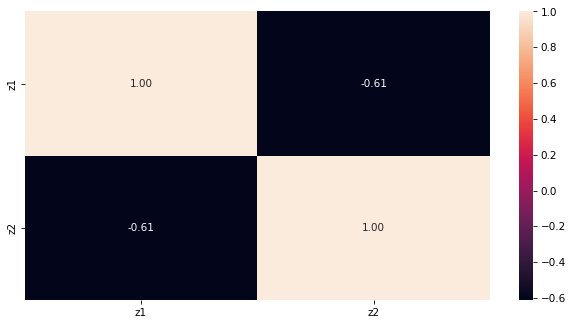

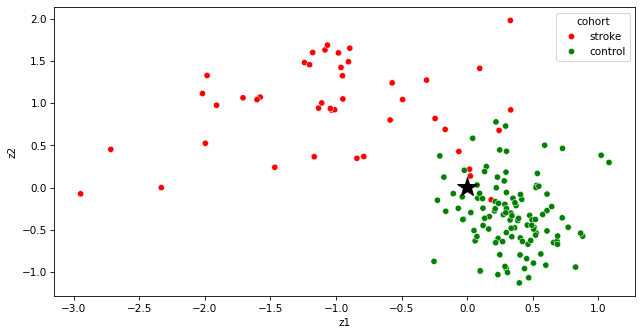

In [249]:
%matplotlib inline
z_plot(z, z_mean)

In [250]:
%matplotlib qt5
betas_hat = skeleton_mode(tangent_vec_all, mu_all_t_tensor, z_mean, std_dev, R, ae_decode)


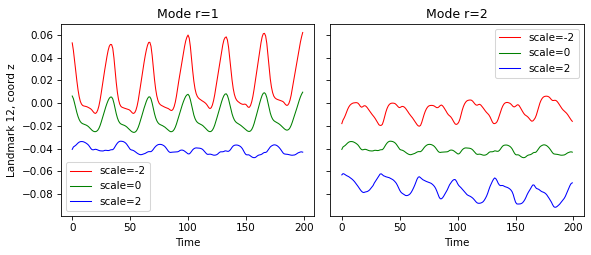

In [251]:
%matplotlib inline
landmark_idx = 12
coord_idx = 2  # z
scales = [-2, 0, 2]

axes = plt.subplots(1, R, figsize=(4 * R, 3.5), sharey=True)[1]
if R == 1:
    axes = [axes]
for r in range(R):
    ax = axes[r]
    for scale_idx, s in enumerate(scales):
        beta = betas_hat[r * len(scales) + scale_idx]  # (K, M, T)
        traj = beta[landmark_idx, coord_idx, :]        # (T,)
        ax.plot(traj, label=f'scale={s}')
    ax.set_title(f'Mode r={r+1}')
    ax.set_xlabel('Time')
    if r == 0:
        ax.set_ylabel(f'Landmark {landmark_idx}, coord z')
    ax.legend()
plt.tight_layout()
plt.show()

## VAE

In [84]:
class LinearVAE(nn.Module):
    """VAE with same encoder/decoder as LinearAE: single W (tied), plus separate logvar head."""
    def __init__(self, D, R):
        super().__init__()
        self.W = nn.Linear(D, R, bias=False)   # encoder mean (same as AE)
        self.fc_logvar = nn.Linear(D, R)       # only extra: variance head

    def encode(self, x):
        mu = self.W(torch.tanh(x))
        logvar = self.fc_logvar(torch.tanh(x))
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return F.linear(z, self.W.weight.T)    # tied decoder (same as AE)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar, z


def vae_loss(x, x_hat, mu, logvar, beta=1e-4):
    recon = ((x_hat - x)**2).sum(dim=1)
    kl = 0.5 * (logvar.exp() + mu.pow(2) - 1 - logvar).sum(dim=1)
    return (recon + beta * kl).mean(), recon.mean(), kl.mean()


In [94]:
deterministic()
dtype = torch.float32
X = torch.from_numpy(tangent_flat.T.astype(np.float32)).to(device=device, dtype=dtype)

D = X.shape[1]
R = 5
beta = 1e-6

model = LinearVAE(D, R).to(device=device, dtype=dtype)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for i in range(3000):
    opt.zero_grad(set_to_none=True)
    X_hat, mu, logvar, z = model(X)
    loss, recon, kl = vae_loss(X, X_hat, mu, logvar, beta=beta)

    loss.backward()
    opt.step()

    if i % 200 == 0:
        print(f"Epoch {i} | Loss {loss.item():.6f} | Recon {recon.item():.6f} | KL {kl.item():.6f}")


Epoch 0 | Loss 4.355564 | Recon 4.355564 | KL 0.000171
Epoch 200 | Loss 2.309134 | Recon 2.309134 | KL 0.489891
Epoch 400 | Loss 2.181869 | Recon 2.181868 | KL 0.719860
Epoch 600 | Loss 2.055242 | Recon 2.055241 | KL 0.898251
Epoch 800 | Loss 1.986109 | Recon 1.986108 | KL 1.120448
Epoch 1000 | Loss 1.996059 | Recon 1.996058 | KL 1.309352
Epoch 1200 | Loss 1.973233 | Recon 1.973231 | KL 1.539244
Epoch 1400 | Loss 1.941272 | Recon 1.941270 | KL 1.864275
Epoch 1600 | Loss 1.827643 | Recon 1.827641 | KL 2.442965
Epoch 1800 | Loss 1.745203 | Recon 1.745200 | KL 2.955734
Epoch 2000 | Loss 1.737153 | Recon 1.737150 | KL 3.315088
Epoch 2200 | Loss 1.705617 | Recon 1.705613 | KL 3.909893
Epoch 2400 | Loss 1.615102 | Recon 1.615098 | KL 4.617037
Epoch 2600 | Loss 1.576573 | Recon 1.576568 | KL 5.165366
Epoch 2800 | Loss 1.550406 | Recon 1.550400 | KL 5.577619


In [195]:
%matplotlib qt5
plot_one_traj(exp_gpu(mu_all_t_tensor, X_hat[1,:].reshape(32,3,tslen)))

torch.Size([155, 5]) torch.Size([1, 5]) torch.Size([5])


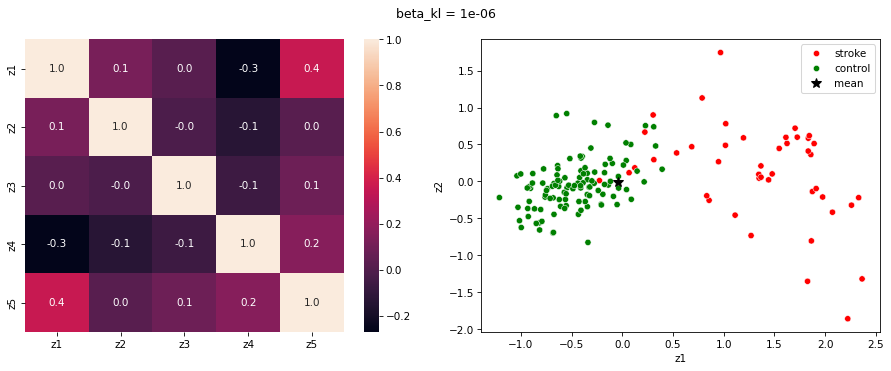

In [95]:
%matplotlib inline
model.eval()

def vae_encode(x):
    mu,_ = model.encode(x)
    return mu

def vae_decode(z):
    return model.decode(z)

def vae_reparameterize(x):
    mu, logvar = model.encode(x)
    return model.reparameterize(mu, logvar)

z, z_mean, std_dev = z_create(X, vae_encode, mu_all_t_tensor)
print(z.shape, z_mean.shape, std_dev.shape)
z_plot(z, z_mean, beta=beta)

In [96]:
%matplotlib qt5
betas_hat = skeleton_mode(tangent_vec_all, mu_all_t_tensor, z_mean, std_dev, 5, vae_decode)

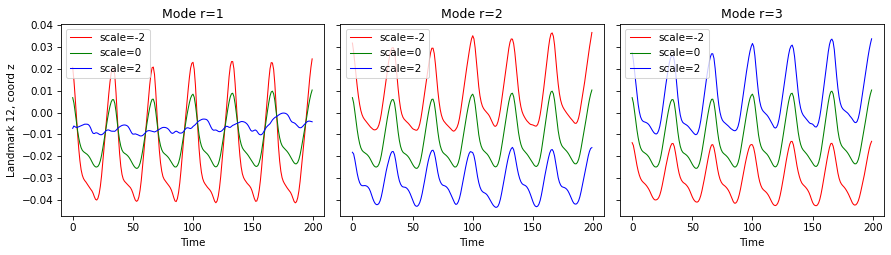

In [83]:
%matplotlib inline
landmark_idx = 12
coord_idx = 2  # z
scales = [-2, 0, 2]

R=3

axes = plt.subplots(1, R, figsize=(4 * R, 3.5), sharey=True)[1]
if R == 1:
    axes = [axes]
for r in range(R):
    ax = axes[r]
    for scale_idx, s in enumerate(scales):
        beta = betas_hat[r * len(scales) + scale_idx]  # (K, M, T)
        traj = beta[landmark_idx, coord_idx, :]        # (T,)
        ax.plot(traj, label=f'scale={s}')
    ax.set_title(f'Mode r={r+1}')
    ax.set_xlabel('Time')
    if r == 0:
        ax.set_ylabel(f'Landmark {landmark_idx}, coord z')
    ax.legend()
plt.tight_layout()
plt.show()

## RVAE

In [12]:
class KendallRVAE(nn.Module):
    """rVAE: encode tangent vectors, decode to tangent, but (during
    training) compare reconstructions on the manifold via an exp map.

    - Inputs: tangent vectors (N, D) as in the VAE section.
    - Decoder: produces tangent vectors.
    - Training loss: uses expmap(mu, v_hat) vs. original manifold trajectory.
    """
    def __init__(self, base_vae, mu_shape, expmap, logmap):
        super().__init__()
        self.vae = base_vae
        # mean shape, used for exponential map when mapping back to manifold
        self.register_buffer("mu_shape", mu_shape)
        self.expmap = expmap
        self.logmap = logmap

    def forward(self, x):
        """Forward on tangent vectors.

        x : (N, D) tangent vectors
        Returns
        -------
        x_man_hat : (N, D) manifold trajectory flattened (via expmap)
        mu_z, logvar, z, v_hat : usual VAE outputs (in tangent space)
        """
        v_hat, mu_z, logvar, z = self.vae(x)   # tangent reconstruction

        # Map reconstructed tangent field back to the manifold
        B = v_hat.shape[0]
        v_hat_reshaped = v_hat.view(B, K, M, T)
        mu = self.mu_shape.view(K, M, T)
        x_recon_man = self.expmap(mu, v_hat_reshaped)   # (B, K, M, T)
        x_recon_man = x_recon_man.view(B, -1)

        return x_recon_man, mu_z, logvar, z, v_hat

In [13]:
betas = np.array(betas_aligned_all)
print(betas.shape)   # (155, 32, 3, 200)

N, K, M, T = betas.shape   # correct order

# Shape mean as before (kept for potential manifold utilities)
mu_shape = torch.from_numpy(
    mu_all_t.reshape(-1).astype(np.float32)
).to(device)

print("mu_shape:", mu_shape.shape)      # should be (19200,)

(155, 32, 3, 200)
mu_shape: torch.Size([19200])


In [23]:
dtype = torch.float32

# Tangent input (as in the VAE section)
X_tan = torch.from_numpy(tangent_flat.T.astype(np.float32)).to(device=device, dtype=dtype)
mu_shape = mu_shape.to(device=device, dtype=dtype)

# Corresponding manifold trajectories (flattened)
betas = np.array(betas_aligned_all)              # (N, K, M, T)
X_man = torch.from_numpy(betas.reshape(betas.shape[0], -1).astype(np.float32)).to(device=device, dtype=dtype)

D = X_tan.shape[1]
R = 10

base_vae = LinearVAE(D, R).to(device=device, dtype=dtype)
model = KendallRVAE(base_vae, mu_shape, exp_gpu_batch, log_gpu_batch).to(device=device, dtype=dtype)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(3000):
    opt.zero_grad(set_to_none=True)

    # forward in tangent space, loss in manifold space
    x_hat_man, mu, logvar, z, v_hat = model(X_tan)

    # Geodesic reconstruction loss on the manifold
    dist = squared_geodesic_distance(X_man, x_hat_man, K, M, T)
    recon = torch.mean(dist)

    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss = recon + 2 * kl

    loss.backward()
    opt.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | loss {loss:.6f} | recon {recon:.6f} | kl {kl:.6f}")
    

Epoch 0 | loss 0.030291 | recon 0.030206 | kl 0.000042
Epoch 200 | loss 0.013937 | recon 0.013791 | kl 0.000073
Epoch 400 | loss 0.014105 | recon 0.013917 | kl 0.000094
Epoch 600 | loss 0.013896 | recon 0.013790 | kl 0.000053
Epoch 800 | loss 0.013970 | recon 0.013796 | kl 0.000087
Epoch 1000 | loss 0.013960 | recon 0.013814 | kl 0.000073
Epoch 1200 | loss 0.013938 | recon 0.013803 | kl 0.000067
Epoch 1400 | loss 0.013912 | recon 0.013780 | kl 0.000066
Epoch 1600 | loss 0.013977 | recon 0.013803 | kl 0.000087
Epoch 1800 | loss 0.013924 | recon 0.013770 | kl 0.000077
Epoch 2000 | loss 0.013927 | recon 0.013787 | kl 0.000070
Epoch 2200 | loss 0.013921 | recon 0.013757 | kl 0.000082
Epoch 2400 | loss 0.013977 | recon 0.013743 | kl 0.000117
Epoch 2600 | loss 0.013935 | recon 0.013774 | kl 0.000081
Epoch 2800 | loss 0.013850 | recon 0.013735 | kl 0.000058


In [31]:
%matplotlib qt5
plot_one_traj(x_hat_man[1,:].reshape(32,3,tslen))

In [29]:
model.eval()

with torch.no_grad():
    # latent means for the tangent-input rVAE
    def rvae_encode(x):
        mu, _ = model.vae.encode(x)
        return mu

    def rvae_decode(z):
        return model.vae.decode(z)

    eigvals, eigvecs, z_mean, Z = latent_pca_stats(X_tan, rvae_encode)

print(eigvals.shape, eigvecs.shape, z_mean.shape)

torch.Size([10]) torch.Size([10, 10]) torch.Size([1, 10])


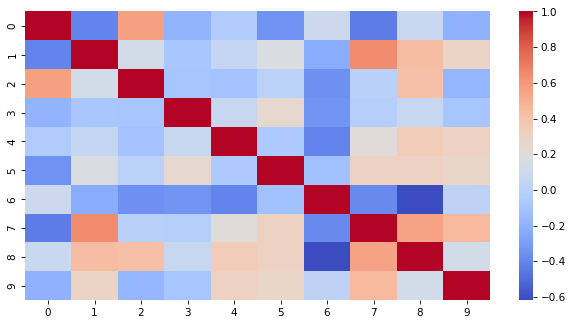

In [36]:
%matplotlib inline
sns.heatmap(pd.DataFrame(Z.cpu().numpy()).corr(), cmap='coolwarm', fmt=".2f")
plt.show()

In [38]:
# ensure Z is a torch.Tensor on the same device as eigvecs
if isinstance(Z, np.ndarray):
    Z_tensor = torch.from_numpy(Z).to(eigvecs.device)
else:
    Z_tensor = Z.to(eigvecs.device)

Z_centered = Z_tensor - z_mean        # shape: [N, latent_dim]
Z_pc = Z_centered @ eigvecs          # principal-component coordinates, [N, latent_dim]

# optional: move to numpy for further analysis / saving
Z_pc_np = Z_pc.cpu().numpy()
print(Z_pc_np.shape)

Z_pc_df = pd.DataFrame(Z_pc_np, columns=["z{}".format(i+1) for i in range(Z_pc_np.shape[1])])

(155, 10)


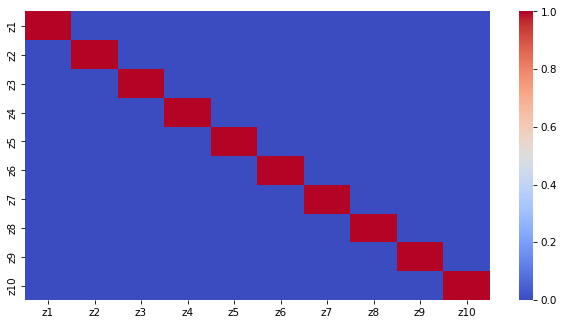

In [39]:
%matplotlib inline
sns.heatmap(Z_pc_df.corr(),cmap='coolwarm', fmt=".2f")
plt.show()

In [40]:
%matplotlib qt5

model.eval()
K, M, T = tangent_vec_all.shape[:3]

# Match the VAE's mode-of-variation construction
scales = [-2, 0, 2]
betas_hat = []

for r in [0]:
    direction = eigvecs[:, r:r+1]

    for s in scales:
        z = z_mean + s * torch.sqrt(eigvals[r]) * direction.T
        with torch.no_grad():
            v = rvae_decode(z)              # tangent vectors
        v = v.reshape(K, M, T)
        beta_hat = exp_gpu(mu_all_t_tensor, v)
        betas_hat.append(beta_hat.detach().cpu().numpy())

    p_all = plotting_betas_landmark([
        betas_hat[-3], betas_hat[-2], betas_hat[-1]
    ], colors=[(1, 0, 0), (0, 0, 0), (0, 0.5, 1)])
    # video_saving(p_all, 'RVAE{}'.format(r+1))

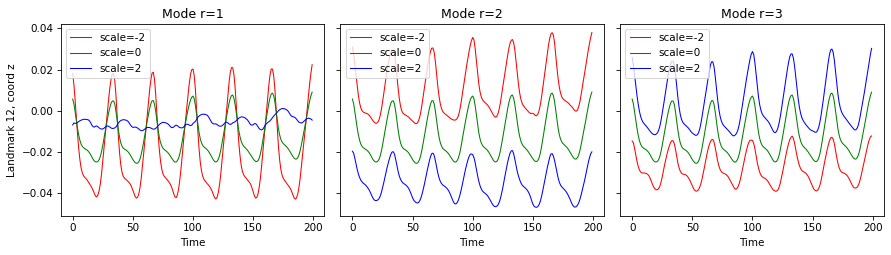

In [24]:
%matplotlib inline
landmark_idx = 12
coord_idx = 2  # z

axes = plt.subplots(1, R, figsize=(4 * R, 3.5), sharey=True)[1]
if R == 1:
    axes = [axes]
for r in range(R):
    ax = axes[r]
    for scale_idx, s in enumerate(scales):
        beta = betas_hat[r * len(scales) + scale_idx]  # (K, M, T)
        traj = beta[landmark_idx, coord_idx, :]        # (T,)
        ax.plot(traj, label=f'scale={s}')
    ax.set_title(f'Mode r={r+1}')
    ax.set_xlabel('Time')
    if r == 0:
        ax.set_ylabel(f'Landmark {landmark_idx}, coord z')
    ax.legend()
plt.tight_layout()
plt.show()